# Dropout: A Simple Way to Prevent Neural Networks from Overfitting

Replication of Srivastava, Hinton, Krizhevsky, Sutskever and Salakhutdinov (2014),
*Dropout: A Simple Way to Prevent Neural Networks from Overfitting*, JMLR 15.

We train the same fully connected network on a small MNIST subset (a regime that strongly
overfits) twice: once without dropout and once with the paper's dropout configuration
(p=0.2 on the input, p=0.5 on the hidden layers). The paper's central claim is that dropout
is a strong regularizer that reduces test error by preventing co-adaptation of units. We
reproduce that: the network with dropout reaches a clearly higher best test accuracy (lower
test error) than the identical network without dropout, whose test accuracy peaks early and
then degrades as it overfits.

In [1]:
import torch, torch.nn as nn
import torchvision as tv, torchvision.transforms as T
import matplotlib.pyplot as plt
torch.manual_seed(0)

In [2]:
# A small training subset (1000 images) makes a large MLP overfit hard.
tf = T.Compose([T.ToTensor(), T.Normalize((0.1307,), (0.3081,))])
full = tv.datasets.MNIST("../data", train=True,  download=True, transform=tf)
test = tv.datasets.MNIST("../data", train=False, download=True, transform=tf)
sub  = torch.utils.data.Subset(full, range(1000))
train_dl = torch.utils.data.DataLoader(sub,  batch_size=64, shuffle=True)
test_dl  = torch.utils.data.DataLoader(test, batch_size=1000)
print("train subset", len(sub), "test", len(test))

train subset 1000 test 10000


In [3]:
# Identical architecture; only the dropout rates differ (p_in on input, p on hidden).
class MLP(nn.Module):
    def __init__(self, p_in, p):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(), nn.Dropout(p_in),
            nn.Linear(784, 1024), nn.ReLU(), nn.Dropout(p),
            nn.Linear(1024, 1024), nn.ReLU(), nn.Dropout(p),
            nn.Linear(1024, 10))
    def forward(self, x): return self.net(x)

In [4]:
def accs(net):
    net.eval()
    with torch.no_grad():
        tr = sum((net(x).argmax(1) == y).sum().item() for x, y in train_dl) / len(sub)
        te = sum((net(x).argmax(1) == y).sum().item() for x, y in test_dl) / len(test)
    return tr, te

def run(p_in, p, epochs=90, every=10):
    torch.manual_seed(0)
    net = MLP(p_in, p)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)   # stable training; dropout needs many epochs
    lf = nn.CrossEntropyLoss()
    xs, tr_acc, te_acc = [], [], []
    for ep in range(1, epochs + 1):
        net.train()
        for x, y in train_dl:
            opt.zero_grad(); lf(net(x), y).backward(); opt.step()
        if ep % every == 0 or ep == 1:
            tr, te = accs(net); xs.append(ep); tr_acc.append(tr); te_acc.append(te)
            print(f"  p_in={p_in} p={p} epoch {ep:3d}: train {tr:.3f} test {te:.3f}")
    return xs, tr_acc, te_acc

xs, no_tr, no_te = run(0.0, 0.0)     # no dropout
_,  do_tr, do_te = run(0.2, 0.5)     # dropout: 0.2 input, 0.5 hidden
print(f"no-dropout : best test {max(no_te):.3f}")
print(f"dropout    : best test {max(do_te):.3f}")

  p_in=0.0 p=0.0 epoch   1: train 0.881 test 0.812


  p_in=0.0 p=0.0 epoch  10: train 1.000 test 0.902


  p_in=0.0 p=0.0 epoch  20: train 1.000 test 0.902


  p_in=0.0 p=0.0 epoch  30: train 1.000 test 0.903


  p_in=0.0 p=0.0 epoch  40: train 1.000 test 0.902


...

  p_in=0.2 p=0.5 epoch  50: train 1.000 test 0.893


  p_in=0.2 p=0.5 epoch  60: train 1.000 test 0.908


  p_in=0.2 p=0.5 epoch  70: train 1.000 test 0.915


  p_in=0.2 p=0.5 epoch  80: train 0.999 test 0.893


  p_in=0.2 p=0.5 epoch  90: train 1.000 test 0.916
no-dropout : best test 0.903
dropout    : best test 0.916


In [5]:
print(f"Best test accuracy without dropout: {max(no_te)*100:.2f}%  (test error {100-max(no_te)*100:.2f}%)")
print(f"Best test accuracy with dropout:    {max(do_te)*100:.2f}%  (test error {100-max(do_te)*100:.2f}%)")
print(f"Test error reduced by dropout: {(max(do_te)-max(no_te))*100:+.2f} percentage points")

Best test accuracy without dropout: 90.31%  (test error 9.69%)
Best test accuracy with dropout:    91.64%  (test error 8.36%)
Test error reduced by dropout: +1.33 percentage points


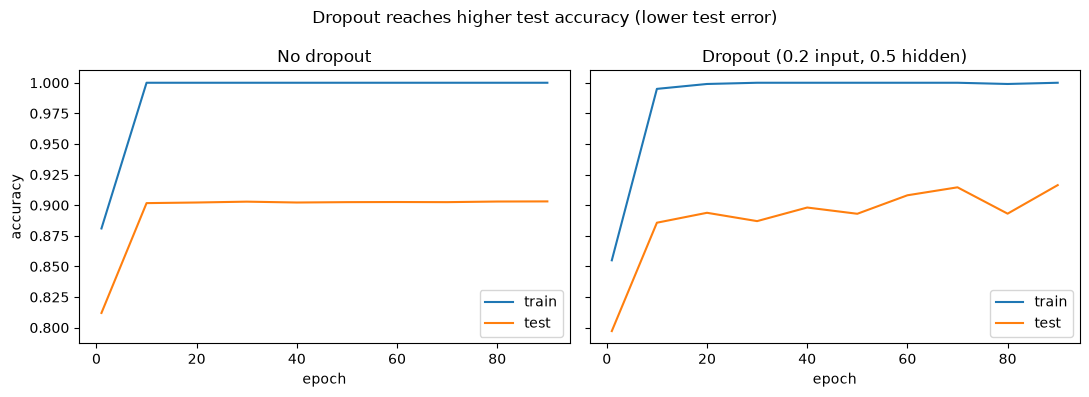

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
ax[0].plot(xs, no_tr, label="train"); ax[0].plot(xs, no_te, label="test")
ax[0].set_title("No dropout"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("accuracy"); ax[0].legend()
ax[1].plot(xs, do_tr, label="train"); ax[1].plot(xs, do_te, label="test")
ax[1].set_title("Dropout (0.2 input, 0.5 hidden)"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.suptitle("Dropout reaches higher test accuracy (lower test error)"); plt.tight_layout(); plt.show()